In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import glob
import polars as pl
import json
import geopandas as gpd
import elapid
from elapid import features as fe
from elapid import GeographicKFold
import rasterio
from rasterio.transform import from_origin
from rasterio.io import MemoryFile
from shapely.ops import unary_union
from scipy import stats
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    precision_score, recall_score, log_loss, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

# Winter: Dec (12), Jan (1), Feb (2) -> 0
# Spring: Mar..May (3..5) -> 1
# Summer: Jun..Aug (6..8) -> 2
# Fall:   Sep..Nov (9..11) -> 3

In [2]:
parambasedir =  '/mnt/f/readyparams/param_csvs'
baseoutputdir = '/mnt/f/readyparams'
sp = 'Protonotaria citrea'
spgroup = 'avian'
aoi = 'mav_counties_4326.parquet'

In [3]:
# Paths
sp = sp.lower().replace(' ', '_')

if "HUGE" in baseoutputdir:
    outputdir = baseoutputdir
else:
    outputdir = os.path.join(baseoutputdir,'ppp_paramsoutput')
    os.makedirs(outputdir, exist_ok=True)
    outputdir = os.path.join(outputdir,sp)
    os.makedirs(outputdir, exist_ok=True)
    
print(outputdir)

pixel_area = 0.01

aoi = gpd.read_parquet(os.path.join(parambasedir,aoi))

/mnt/f/readyparams/ppp_paramsoutput/protonotaria_citrea


In [4]:
# === Load Presence Points ===

# Find matching files
csv_files = glob.glob(os.path.join(parambasedir, f"*{sp}*.csv"))

dfs = []
for file_path in csv_files:
    print(f"Reading: {file_path}")

    # Read CSV
    df = pl.read_csv(file_path)
    # Extract lon/lat
    df = df.with_columns([
        pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][0], return_dtype=pl.Float64).alias("longitude"),
        pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][1], return_dtype=pl.Float64).alias("latitude")
    ])
    
    # Drop unnecessary columns
    df = df.drop(["system:index", ".geo"])
    
    
    dfs.append(df)
    
combined_df = pl.concat(dfs, how='diagonal')

combined_df = combined_df.with_columns(
    pl.lit(1).alias("label")  # constant string
)
len(combined_df)

Reading: /mnt/f/readyparams/param_csvs/protonotaria_citrea_subset0.csv
Reading: /mnt/f/readyparams/param_csvs/protonotaria_citrea_subset1.csv


1591

In [5]:
combined_df

date,day,dayl_mean_mean,dw_class_0_pct_10000m,dw_class_0_pct_500m,dw_class_1_pct_10000m,dw_class_1_pct_500m,dw_class_2_pct_10000m,dw_class_2_pct_500m,dw_class_3_pct_10000m,dw_class_3_pct_500m,dw_class_4_pct_10000m,dw_class_4_pct_500m,dw_class_5_pct_10000m,dw_class_5_pct_500m,dw_class_6_pct_10000m,dw_class_6_pct_500m,dw_class_7_pct_10000m,dw_class_7_pct_500m,dw_class_8_pct_10000m,dw_class_8_pct_500m,month,obs_date,observation_date,prcp_mean_mean,protocol_name,scientific_name,season,tmax_mean_mean,tmin_mean_mean,year,longitude,latitude,label
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,f64,str,str,i64,f64,f64,i64,f64,f64,i32
"""2019-05-28T00:00:00""",28,50227.08,16.166407,40.740741,42.397428,50.617284,5.662539,8.641975,3.593596,0.0,23.054397,0.0,0.280103,0.0,0.356495,0.0,8.489035,0.0,0.0,0.0,5,"""2019-05-28""","""2019-05-28""",5.3199363,"""Stationary""","""protonotaria_citrea""",1,29.142847,19.03181,2019,-91.346537,34.016954,1
"""2019-05-28T00:00:00""",28,50227.08,16.166407,40.740741,42.397428,50.617284,5.662539,8.641975,3.593596,0.0,23.054397,0.0,0.280103,0.0,0.356495,0.0,8.489035,0.0,0.0,0.0,5,"""2019-05-28""","""2019-05-28""",5.3199363,"""Stationary""","""protonotaria_citrea""",1,29.142847,19.03181,2019,-91.346537,34.016954,1
"""2019-05-01T00:00:00""",1,48047.062,6.747939,2.469136,56.950059,91.358025,2.998377,2.469136,3.303944,0.0,26.275583,0.0,0.178247,0.0,0.34058,3.703704,3.205271,0.0,0.0,0.0,5,"""2019-05-01""","""2019-05-01""",6.728776,"""Stationary""","""protonotaria_citrea""",1,25.33139,14.886333,2019,-91.124653,34.369992,1
"""2020-05-10T00:00:00""",10,48955.043,16.522902,41.975309,45.093421,53.08642,4.277939,4.938272,2.072127,0.0,30.362543,0.0,0.420155,0.0,0.321482,0.0,0.929433,0.0,0.0,0.0,5,"""2020-05-10""","""2020-05-10""",6.044572,"""Traveling""","""protonotaria_citrea""",1,25.562529,14.289028,2020,-91.346537,34.016954,1
"""2020-05-03T00:00:00""",3,48288.492,16.729796,41.975309,44.861062,53.08642,4.23656,4.938272,2.240825,0.0,30.429385,0.0,0.426521,0.0,0.318299,0.0,0.757552,0.0,0.0,0.0,5,"""2020-05-03""","""2020-05-03""",5.0361443,"""Traveling""","""protonotaria_citrea""",1,24.60883,13.36103,2020,-91.346537,34.016954,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-04T00:00:00""",4,48895.656,14.145208,4.938272,41.69717,69.135802,6.703377,6.17284,0.111405,0.0,19.836394,1.234568,0.754369,4.938272,13.88102,11.111111,2.871057,2.469136,0.0,0.0,8,"""2024-08-04""","""2024-08-04""",1.934562,"""Stationary""","""protonotaria_citrea""",2,32.475323,21.6566,2024,-90.162558,35.073373,1
"""2024-08-25T00:00:00""",25,46540.84,10.414744,32.098765,54.495974,45.679012,6.264125,0.0,0.216443,1.234568,17.827928,0.0,0.868956,17.283951,8.594073,2.469136,1.317758,1.234568,0.0,0.0,8,"""2024-08-25""","""2024-08-25""",4.1551943,"""Stationary""","""protonotaria_citrea""",2,31.53995,20.45855,2024,-90.149083,34.995219,1
"""2024-08-25T00:00:00""",25,46540.84,10.414744,32.098765,54.495974,45.679012,6.264125,0.0,0.216443,1.234568,17.827928,0.0,0.868956,17.283951,8.594073,2.469136,1.317758,1.234568,0.0,0.0,8,"""2024-08-25""","""2024-08-25""",4.1551943,"""Stationary""","""protonotaria_citrea""",2,31.53995,20.45855,2024,-90.149083,34.995219,1


In [6]:
gdf = gpd.GeoDataFrame(
    combined_df.to_pandas(), 
    geometry=gpd.points_from_xy(combined_df["longitude"], combined_df["latitude"]), 
    crs="EPSG:4326"
)

# 3. Create a single Minimum Convex Hull for the entire set
# Use union_all() for GeoPandas 1.0+; unary_union for older versions
convex_hull_geom = gdf.geometry.union_all().convex_hull

# Create a new GeoDataFrame for the output
hull_gdf = gpd.GeoDataFrame({"id": [1], "geometry": [convex_hull_geom]}, crs="EPSG:4326")

# 4. Write to Parquet
hull_gdf.to_file(os.path.join(outputdir,f"convex_hull_{sp}.json"), driver="GeoJSON")


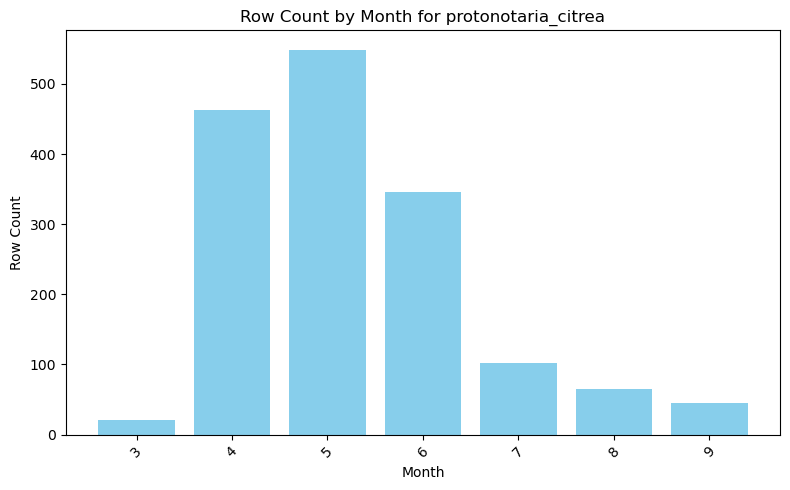

In [7]:
# Ensure 'month' column exists
if "month" not in combined_df.columns:
    combined_df = combined_df.with_columns(
        pl.col("obs_date")
        .str.strptime(pl.Date, format="%Y-%m-%d")  # ✅ use 'format' instead of 'fmt'
        .dt.month()
        .alias("month")
    )

# Count rows by month
month_counts = (
    combined_df
    .group_by("month")
    .len()
    .sort("month")
)

# Convert to pandas for plotting
month_counts_pd = month_counts.to_pandas()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(month_counts_pd["month"], month_counts_pd["len"], color="skyblue")
plt.title(f"Row Count by Month for {sp}")
plt.xlabel("Month")
plt.ylabel("Row Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(outputdir,f"CountByMonth_{sp}.png"))
plt.show()

In [8]:
csv_files = glob.glob(os.path.join(parambasedir, f"background*{spgroup}*.csv"))

bgs = []
for file_path in csv_files:
    print(f"Reading: {file_path}")

    # Read CSV
    bg = pl.read_csv(file_path)
    # Extract lon/lat
    #bg = bg.with_columns([
    #    pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][0], return_dtype=pl.Float64).alias("longitude"),
    #    pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][1], return_dtype=pl.Float64).alias("latitude")
    #])
    # Drop unnecessary columns
    #bg = bg.drop(["system:index", ".geo"])
    bgs.append(bg)
    
combined_bg = pl.concat(bgs, how='diagonal')
combined_bg = combined_bg.with_columns(
    pl.lit(0).alias("label")  # constant string
)

Reading: /mnt/f/readyparams/param_csvs/background_avian.csv


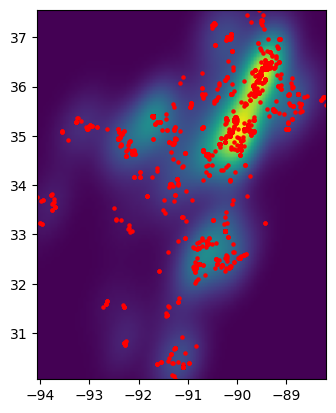

In [9]:
x = combined_df["longitude"]
y = combined_df["latitude"]
xy = np.vstack([x,y])
kde = stats.gaussian_kde(xy)
# To get density at specific points (e.g., a grid for plotting)
# Create a meshgrid
xmin, ymin = x.min(), y.min()
xmax, ymax = x.max(), y.max()
X, Y = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
# Evaluate the KDE on the grid
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
plt.imshow(Z, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='viridis')
plt.scatter(x, y, s=5, c='red')
plt.show()

<Axes: >

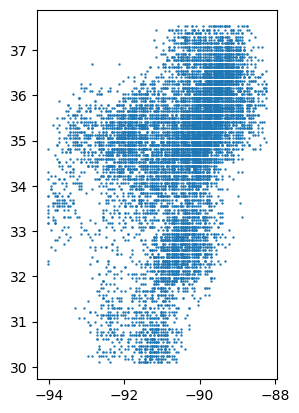

In [10]:
xres = (xmax - xmin) / Z.shape[1]
yres = (ymax - ymin) / Z.shape[0]
transform = from_origin(xmin, ymax, xres, yres)

Z_clean = np.nan_to_num(Z, nan=0.0)
Z_clean[Z_clean < 0] = 0.0
Z_raster = np.flipud(Z_clean)  # <-- important

with rasterio.Env():
    with MemoryFile() as memfile:
        with memfile.open(
            driver="GTiff",
            height=Z_raster.shape[0],
            width=Z_raster.shape[1],
            count=1,
            dtype=Z_raster.dtype,
            crs="EPSG:4326",
            transform=transform,
        ) as dataset:
            dataset.write(Z_raster, 1)

        vsi_path = memfile.name
        pseudoabsence_bias = elapid.sample_bias_file(vsi_path, 10000)

# done; no files written to disk
pseudoabsence_bias.plot(markersize=0.5)

Total presence points: 1591
Total background points: 2310


/home/mike/miniforge3/envs/rapids-25.10/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


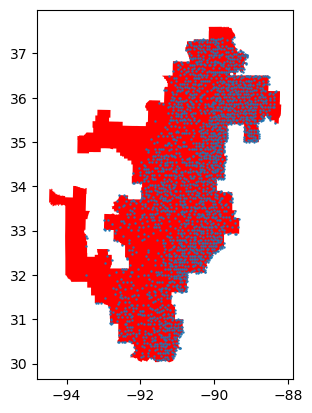

In [11]:
geometry = gpd.points_from_xy(combined_bg["longitude"], combined_bg["latitude"])
bgdf = gpd.GeoDataFrame(combined_bg.to_pandas().copy(), geometry=geometry, crs="EPSG:4326")
pseudo = gpd.GeoDataFrame(geometry=pseudoabsence_bias, crs="EPSG:4326")


A_with_nearest_B = gpd.sjoin_nearest(
    pseudo,bgdf,
    how="left",             # keep all A rows
    distance_col="dist_m"   # name the output distance column
)

# ---- Remove duplicates (keep only unique B points) ----
unique_b_idxs = (
    A_with_nearest_B["index_right"]
    .dropna()
    .astype(int)
    .unique()
)
B_for_each_A = bgdf.loc[unique_b_idxs].reset_index(drop=True)

fig, ax = plt.subplots()
aoi.plot(ax=ax, color='red') 
B_for_each_A.plot(ax=ax,markersize=0.5)

print('Total presence points:',len(combined_df))
print('Total background points:',len(B_for_each_A))

summary = pd.Series([
    f"Total presence points: {len(combined_df)}",
    f"Total background points: {len(B_for_each_A)}"
])

summary.to_csv(
    os.path.join(outputdir, f"PointNums_{sp}.txt"),
    index=False,
    header=False
)


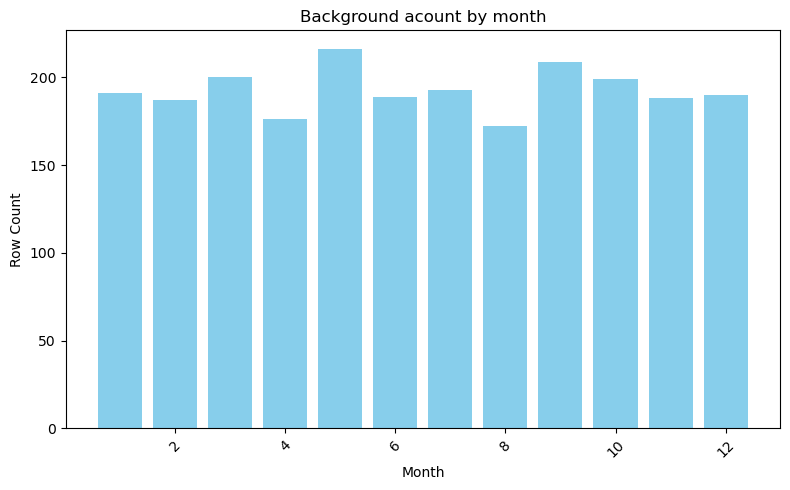

In [12]:
# Count rows by month
combined_bg = pl.from_pandas(B_for_each_A.drop(columns='geometry'))
combined_bg = combined_bg.with_columns(
    pl.col("obs_date").str.to_datetime(strict=False).dt.month().alias("month")
)

month_counts = (
    combined_bg
    .group_by("month")
    .len()
    .sort("month")  # optional: sort chronologically if month is numeric or formatted
)

# Convert to pandas for plotting
month_counts_pd = month_counts.to_pandas()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(month_counts_pd["month"], month_counts_pd["len"], color="skyblue")
plt.title(f"Background acount by month")
plt.xlabel("Month")
plt.ylabel("Row Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# ------------------------
# === Prepare Data ===
# ------------------------
data = pd.concat([combined_df.to_pandas(), combined_bg.to_pandas()], ignore_index=True)
#geometry = gpd.points_from_xy(data["longitude"], data["latitude"])
#gdf = gpd.GeoDataFrame(data.copy(), geometry=geometry, crs="EPSG:4326")
#gdf = gdf.to_crs(5070)
# Keep coords for spatial CV
coords = data[["longitude", "latitude"]].to_numpy()

# Drop non-predictor columns (keep coords only in 'coords', not in X)
X = data.drop(columns=[
    'basisofrecord', 'coordinateuncertaintyinmeters', 'species', 'rand',
    'date', 'day', 'obs_date', 'observation_date', 'protocol_name',
    'scientific_name', 'year', 'label', 'month',
    'srad_mean_mean', 'swe_mean_mean', 'vp_mean_mean'
], errors='ignore').copy()
#sample_weight = elapid.distance_weights(gdf, n_neighbors=-1)
# Labels: 1 = presence, 0 = background (PPP/MaxEnt presence-background)
y = data['label'].astype(int)
X = X.fillna(0)
X.columns = [col.replace('_mean_mean', '_10000m') for col in X.columns]
print(X.columns)

#Drop additional columns
X = X.drop(columns=['dayl_10000m', 'dw_class_8_pct_10000m', 'dw_class_8_pct_500m'])
print('')
print('### covariate list ###')
print(len(X.columns))
print(X.columns)

Index(['dayl_10000m', 'dw_class_0_pct_10000m', 'dw_class_0_pct_500m',
       'dw_class_1_pct_10000m', 'dw_class_1_pct_500m', 'dw_class_2_pct_10000m',
       'dw_class_2_pct_500m', 'dw_class_3_pct_10000m', 'dw_class_3_pct_500m',
       'dw_class_4_pct_10000m', 'dw_class_4_pct_500m', 'dw_class_5_pct_10000m',
       'dw_class_5_pct_500m', 'dw_class_6_pct_10000m', 'dw_class_6_pct_500m',
       'dw_class_7_pct_10000m', 'dw_class_7_pct_500m', 'dw_class_8_pct_10000m',
       'dw_class_8_pct_500m', 'prcp_10000m', 'season', 'tmax_10000m',
       'tmin_10000m', 'longitude', 'latitude'],
      dtype='object')

### covariate list ###
22
Index(['dw_class_0_pct_10000m', 'dw_class_0_pct_500m', 'dw_class_1_pct_10000m',
       'dw_class_1_pct_500m', 'dw_class_2_pct_10000m', 'dw_class_2_pct_500m',
       'dw_class_3_pct_10000m', 'dw_class_3_pct_500m', 'dw_class_4_pct_10000m',
       'dw_class_4_pct_500m', 'dw_class_5_pct_10000m', 'dw_class_5_pct_500m',
       'dw_class_6_pct_10000m', 'dw_class_6_pct_500

In [14]:
import re

# Standard mapping (adjust if you prefer different names)
label_map = {
    '0': 'water',
    '1': 'trees',
    '2': 'grass',
    '3': 'flooded_vegetation',
    '4': 'crops',
    '5': 'shrub_and_scrub',
    '6': 'built',
    '7': 'bare',
    '8': 'snow_and_ice',
}

pattern = re.compile(r'^dw_class_(\d)_pct_(\d+)m$')

def rename_col(c):
    m = pattern.match(c)
    if not m:
        return c
    class_id, scale = m.group(1), m.group(2)
    label = label_map.get(class_id)
    if label is None:
        return c
    return f'{label}_{scale}m'

#X= X.rename(columns=rename_col)
print(X.columns)

Index(['dw_class_0_pct_10000m', 'dw_class_0_pct_500m', 'dw_class_1_pct_10000m',
       'dw_class_1_pct_500m', 'dw_class_2_pct_10000m', 'dw_class_2_pct_500m',
       'dw_class_3_pct_10000m', 'dw_class_3_pct_500m', 'dw_class_4_pct_10000m',
       'dw_class_4_pct_500m', 'dw_class_5_pct_10000m', 'dw_class_5_pct_500m',
       'dw_class_6_pct_10000m', 'dw_class_6_pct_500m', 'dw_class_7_pct_10000m',
       'dw_class_7_pct_500m', 'prcp_10000m', 'season', 'tmax_10000m',
       'tmin_10000m', 'longitude', 'latitude'],
      dtype='object')


In [15]:
# Test removing 10km columns
'''
dw_cols = X.columns[X.columns.str.contains('dw_class') & X.columns.str.contains('10000m')]
# Explicit additional columns to drop
extra_cols = ['forest_edge_10000', 'forest_core_pct_10000']
# Combine them
cols_to_drop = list(dw_cols) + extra_cols
# Drop from dataframe
X_filtered = X.drop(columns=cols_to_drop, errors='ignore')

X = X.drop(columns= ['forest_edge_10000', 'forest_core_pct_10000', 'forest_core_pct_100', 'tmax_10000m','dw_class_0_pct_10000m','dw_class_1_pct_10000m','dw_class_2_pct_10000m','dw_class_3_pct_10000m', 'dw_class_4_pct_10000m','dw_class_5_pct_10000m',
                     'dw_class_6_pct_10000m','dw_class_7_pct_10000m','dw_class_8_pct_10000m','forest_core_pct_10000'])
'''
target_vars = X.drop(columns= ['latitude', 'longitude']).columns

print(X.columns)
if len(combined_df) <= len(target_vars):
    raise SystemExit("Not enough presence records")

Index(['dw_class_0_pct_10000m', 'dw_class_0_pct_500m', 'dw_class_1_pct_10000m',
       'dw_class_1_pct_500m', 'dw_class_2_pct_10000m', 'dw_class_2_pct_500m',
       'dw_class_3_pct_10000m', 'dw_class_3_pct_500m', 'dw_class_4_pct_10000m',
       'dw_class_4_pct_500m', 'dw_class_5_pct_10000m', 'dw_class_5_pct_500m',
       'dw_class_6_pct_10000m', 'dw_class_6_pct_500m', 'dw_class_7_pct_10000m',
       'dw_class_7_pct_500m', 'prcp_10000m', 'season', 'tmax_10000m',
       'tmin_10000m', 'longitude', 'latitude'],
      dtype='object')


In [16]:
def plot_elapid_responses(model, training_data, target_var, title="Response Curve"):
    """
    Plots the marginal response for a single variable.
    """
    # 1. Create a range of values for the target variable
    v_min, v_max = training_data[target_var].min(), training_data[target_var].max()
    v_range = np.linspace(v_min, v_max, 100)
    
    # 2. Create a 'mean' background: all other vars at their mean
    mean_data = training_data.mean(axis=0).to_frame().T
    # Repeat it 100 times
    eval_df = pd.concat([mean_data] * 100, ignore_index=True)
    
    # 3. Replace the target variable with our range
    eval_df[target_var] = v_range
    
    # 4. Predict suitability (cloglog or logistic)
    preds = model.predict(eval_df)

    # rename target_var
    target_var = rename_col(target_var)
    # 5. Plot
    plt.plot(v_range, preds)
    plt.xlabel(f"{target_var} value")
    plt.ylabel("Suitability")
    plt.title(f"{title}: {target_var}")
    plt.grid(True, alpha=0.3)

In [17]:
def fit_maxent_with_tuning(
    X: "pd.DataFrame",
    y: "pd.Series",
    #sw: "np.ndarray",
    coords: "np.ndarray",
    outputdir: str,
    sp: str,
    selection_metric: str = "best_f1",  # or "mean_auc"
    target_vars=None,
    base_tau: float = 0.5,
    n_splits: int = 5,
    random_state: int = 42,
    reg_values: "list[float]" = None,
    feature_types: "list[str]" = None,
    n_cpus: int = 8
):

    # ---------- setup ----------
    os.makedirs(outputdir, exist_ok=True)

    # Work on copies; avoid chained assignment warnings
    X = X.copy()
    y = y.astype(int).copy()

    #setting sample weights to a df for train/test partitions
    #if isinstance(sw, np.ndarray):
    #    sw = pd.Series(sw, index=y.index, name="sample_weight")
    
    n_pres = int(y.sum())

    # Conservative features for very small n (mirror MaxEnt guidance)
    if feature_types is None:
        feature_types = ["linear", "quadratic"] if n_pres < 10 else ["linear", "quadratic", "hinge"]
    # Remove hinge
    feature_types = ["linear", "quadratic", "product"]
    
    # Wider sweep for small n
    if reg_values is None:
        reg_values = [1.5, 2.0, 3.0, 4.0] if n_pres < 10 else [0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
    reg_values = [0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
    
    # ---------- build spatial folds ONCE (preferred); fallback to stratified ----------
    try:
        from elapid import GeographicKFold
        gkf = GeographicKFold(n_splits=n_splits)
        geometry = gpd.points_from_xy(X["longitude"], X["latitude"])
        gdf_coords = gpd.GeoDataFrame(X[["longitude", "latitude"]], geometry=geometry, crs="EPSG:4326")
        folds = list(gkf.split(gdf_coords))
        cv_name = "GeographicKFold"
    except Exception as e:
        print('Not using GeographicKFold:',e)
        folds = list(StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state).split(X, y))
        cv_name = "StratifiedKFold"
    print('Fold type:',cv_name)
    # ---------- regularization sweep ----------
    reg_results = []
    X = X.drop(columns=["longitude", "latitude"])
    for reg in reg_values:
        model_alpha = elapid.MaxentModel(
            feature_types=feature_types,
            tau=base_tau,
            clamp=True,
            scorer="roc_auc",           # internal elapid scorer for its own CV
            beta_multiplier=reg,
            beta_lqp=1.0,
            beta_hinge=1.0,
            beta_threshold=1.0,
            beta_categorical=1.0,
            n_hinge_features=10,
            n_threshold_features=10,
            convergence_tolerance=1e-4,
            use_lambdas="best",
            n_cpus=n_cpus
        )

        all_y_true_alpha, all_y_pred_prob_alpha = [], []
        aucs_alpha = []

        for train_idx, test_idx in folds:
            X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
            y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
            #sw_train, sw_test = sw.iloc[train_idx].copy(), sw.iloc[test_idx].copy()

            model_alpha.fit(X_train, y_train)#, sample_weight=sw_train)
            y_pred_prob_alpha = model_alpha.predict(X_test)

            all_y_true_alpha.extend(y_test)
            all_y_pred_prob_alpha.extend(y_pred_prob_alpha)

            # AUC per fold (guard: requires both classes)
            if len(np.unique(y_test)) > 1:
                fpr, tpr, _ = roc_curve(y_test, y_pred_prob_alpha)
                aucs_alpha.append(auc(fpr, tpr))

        all_y_true_alpha = np.array(all_y_true_alpha)
        all_y_pred_prob_alpha = np.array(all_y_pred_prob_alpha)

        # F1 on concatenated predictions (threshold-independent sweep)
        precisions_alpha, recalls_alpha, thresholds_alpha = precision_recall_curve(all_y_true_alpha, all_y_pred_prob_alpha)
        f1_scores_alpha = 2 * (precisions_alpha * recalls_alpha) / (precisions_alpha + recalls_alpha + 1e-9)
        best_f1_alpha = float(np.max(f1_scores_alpha))
        mean_auc_alpha = float(np.mean(aucs_alpha)) if len(aucs_alpha) else float("nan")

        reg_results.append({
            "beta_multiplier": reg,
            "best_f1": best_f1_alpha,
            "mean_auc": mean_auc_alpha,
        })

    # Save tuning table
    reg_df = pd.DataFrame(reg_results)
    reg_df.to_csv(os.path.join(outputdir, f"Regularization_{sp}.csv"), index=False)

    # Plot F1 vs beta_multiplier
    plt.figure(figsize=(10, 5))
    plt.plot(reg_df["beta_multiplier"], reg_df["best_f1"], marker="o", label="Best F1")
    plt.xscale("log")
    plt.xlabel("beta_multiplier (log scale)")
    plt.ylabel("Best F1")
    plt.title(f"Effect of Regularization on F1 ({cv_name})")
    plt.grid(True)
    plt.legend()
    plt.savefig(os.path.join(outputdir, f"Regularization_F1_{sp}.png"))
    plt.show()

    # Plot AUC vs beta_multiplier (diagnostic; may be NaN if folds were single-class)
    plt.figure(figsize=(10, 5))
    plt.plot(reg_df["beta_multiplier"], reg_df["mean_auc"], marker="o", color="orange", label="Mean AUC")
    plt.xscale("log")
    plt.xlabel("beta_multiplier (log scale)")
    plt.ylabel("Mean AUC")
    plt.title(f"Effect of Regularization on AUC ({cv_name})")
    plt.grid(True)
    plt.legend()
    plt.savefig(os.path.join(outputdir, f"Regularization_AUC_{sp}.png"))
    plt.show()

    # ---------- select best regularization ----------
    sel = "best_f1" if selection_metric not in {"best_f1", "mean_auc"} else selection_metric
    if sel == "mean_auc":
        # if all AUCs are NaN (e.g., tiny species), fall back to F1
        if np.all(np.isnan(reg_df["mean_auc"].values)):
            sel = "best_f1"

    best_entry = max(reg_results, key=lambda r: r[sel] if not np.isnan(r[sel]) else -np.inf)
    best_beta = best_entry["beta_multiplier"]
    best_score = best_entry[sel]
    print(f"✅ Selected beta_multiplier={best_beta} (CV {sel}={best_score:.4f})")

    # Persist selection
    with open(os.path.join(outputdir, f"best_beta_{sp}.txt"), "w") as f:
        f.write(str(best_beta))

    # ---------- final refit on ALL data ----------
    final_model = elapid.MaxentModel(
        feature_types=feature_types,
        tau=base_tau,
        clamp=True,
        scorer="roc_auc",
        beta_multiplier=best_beta,
        beta_lqp=1.0,
        beta_hinge=1.0,
        beta_threshold=1.0,
        beta_categorical=1.0,
        n_hinge_features=10,
        n_threshold_features=10,
        convergence_tolerance=1e-4,
        use_lambdas="best",
        n_cpus=n_cpus
    )
    
    final_model.fit(X, y)#, sample_weight = sample_weight)
    y_pred_prob_full = final_model.predict(X)

    # ---------- final diagnostics ----------
    precisions_f, recalls_f, thresholds_f = precision_recall_curve(y, y_pred_prob_full)
    f1_scores_f = 2 * (precisions_f * recalls_f) / (precisions_f + recalls_f + 1e-9)
    idx_f = int(np.argmax(f1_scores_f))
    final_threshold = thresholds_f[idx_f]
    final_f1 = float(f1_scores_f[idx_f])

    if len(np.unique(y)) > 1:
        fpr_f, tpr_f, roc_thresholds_f = roc_curve(y, y_pred_prob_full)
        final_auc = float(auc(fpr_f, tpr_f))
    else:
        final_auc = float("nan")  # AUC undefined with single class in full data

    final_precision = precision_score(y, (y_pred_prob_full >= final_threshold).astype(int))
    final_recall = recall_score(y, (y_pred_prob_full >= final_threshold).astype(int))
    final_logloss = log_loss(y, y_pred_prob_full, labels=[0, 1])
    prevalence = y.mean()

    print(f"🏁 Final tuned model (beta_multiplier={best_beta})")
    print(f"AUC={final_auc:.4f}  Precision={final_precision:.4f}  Recall={final_recall:.4f}  F1={final_f1:.4f}")
    print(f"Best threshold={final_threshold:.4f}  Log-loss={final_logloss:.4f}  Prevalence={prevalence:.4f}")

    #Save raw predictor names used at training for plug-and-play inference
    pd.Series(X.columns).to_csv(os.path.join(outputdir, f"predictors_{sp}.txt"),
                                index=False, header=False)

    # Save final model & metrics BEFORE importance (so refits for importance don’t overwrite it)
    joblib.dump(final_model, os.path.join(outputdir, f"elapid_maxent_model_tuned_{sp}.pkl"))
    np.savetxt(os.path.join(outputdir, f"accuracy_tuned_{sp}.csv"),
               [['beta_multiplier', best_beta],
                ['SelectionMetric', sel],
                ['AUC', final_auc],
                ['Precision', final_precision],
                ['Recall', final_recall],
                ['F1', final_f1],
                ['BestThreshold', final_threshold],
                ['LogLoss', final_logloss],
                ['Prevalence', prevalence]],
               delimiter=',', fmt='%s')

    # Final PR/ROC plots
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(recalls_f, precisions_f, label="PR (final tuned)", color="navy")
    plt.scatter(recalls_f[idx_f], precisions_f[idx_f], color="red", s=80, label=f"Best F1={final_f1:.2f}")
    plt.title(f"PR Curve (beta={best_beta})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    if len(target_vars)>0:
        for var in target_vars:
            plt.figure(figsize=(6, 4))
            plot_elapid_responses(final_model, X, var, title=f"Beta={reg}")
            plt.show()    

    plt.subplot(1, 2, 2)
    if not np.isnan(final_auc):
        # Mark point closest to final_best_threshold (optional)
        roc_thresholds_f = np.linspace(0, 1, len(recalls_f))  # dummy, just for plotting label anchor
        plt.plot(*roc_curve(y, y_pred_prob_full)[:2], label=f"ROC (AUC={final_auc:.2f})", color="darkorange")
    else:
        plt.text(0.5, 0.5, "AUC undefined (single class in y)", ha="center", va="center")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve (beta={best_beta})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(outputdir, f"Curves_tuned_{sp}.png"))
    plt.show()

    # ---------- robust feature importance ----------
    # (1) Try native MaxEnt lambdas + feature names
    lambdas = getattr(final_model, "lambdas_", None)
    names = getattr(final_model, "feature_names_", None)

    if lambdas is not None:
        lambdas = np.asarray(lambdas).ravel()
        if names is None or len(names) != len(lambdas):
            names = [f"feature_{i}" for i in range(len(lambdas))]
        df_imp = pd.DataFrame({
            "feature": names,
            "lambda_weight": lambdas,
            "abs_importance": np.abs(lambdas)
        }).sort_values("abs_importance", ascending=True)
        df_imp.to_csv(os.path.join(outputdir, f"FeatureImportance_Lambdas_{sp}.csv"), index=False)
        plt.figure(figsize=(10, max(6, 0.3 * len(names))))
        plt.barh(df_imp["feature"], df_imp["lambda_weight"], color="skyblue")
        plt.axvline(0, color="gray", linewidth=1)
        plt.title("MaxEnt Feature Importance (lambda weights)")
        plt.xlabel("Lambda weight (positive ↑ suitability)")
        plt.tight_layout()
        plt.savefig(os.path.join(outputdir, f"FeatureImportance_Lambdas_{sp}.png"))
        plt.show()

    else:
        # (2) Permutation importance fallback, safe for single-class holdout
        # Use a fresh model instance so we don't alter the saved final_model
        model_pi = elapid.MaxentModel(
            feature_types=feature_types,
            tau=base_tau,
            clamp=True,
            scorer="roc_auc",
            beta_multiplier=best_beta,
            beta_lqp=1.0,
            beta_hinge=1.0,
            beta_threshold=1.0,
            beta_categorical=1.0,
            n_hinge_features=10,
            n_threshold_features=10,
            convergence_tolerance=1e-4,
            use_lambdas="best",
            n_cpus=n_cpus
        )

        # Stratified split to maximize chance both classes appear
        try:
            #X_train_pi, X_holdout_pi, y_train_pi, y_holdout_pi,sw_train_pi, sw_holdout_pi = train_test_split(
            X_train_pi, X_holdout_pi, y_train_pi, y_holdout_pi = train_test_split(
                X, y, test_size=0.2, random_state=random_state, stratify=y
            )
        except ValueError:
            # If stratify fails (e.g., no positives), fall back to simple split
            split = int(0.8 * len(X))
            X_train_pi, X_holdout_pi = X.iloc[:split].copy(), X.iloc[split:].copy()
            y_train_pi, y_holdout_pi = y.iloc[:split].copy(), y.iloc[split:].copy()
            #sw_train_pi, sw_holdout_pi = sw.iloc[:split].copy(), sw.iloc[split:].copy()
            
        model_pi.fit(X_train_pi, y_train_pi)#, sample_weight = sw_train_pi)

        # Robust baseline: prefer AUC (if both classes), else use −log_loss
        def baseline_score(y_true, y_prob):
            if len(np.unique(y_true)) > 1:
                return roc_auc_score(y_true, y_prob)
            return -log_loss(y_true, y_prob, labels=[0, 1])

        base_score = baseline_score(y_holdout_pi, model_pi.predict(X_holdout_pi))

        # Robust scorer for permutation importance
        def robust_prob_scorer(est, X_eval, y_eval):
            y_prob = est.predict(X_eval)  # elapid returns 1D prob of presence
            if len(np.unique(y_eval)) > 1:
                return roc_auc_score(y_eval, y_prob)
            return -log_loss(y_eval, y_prob, labels=[0, 1])

        perm = permutation_importance(
            model_pi,
            X_holdout_pi,
            y_holdout_pi,
            scoring=robust_prob_scorer,
            n_repeats=10
        )

        imp = pd.DataFrame({
            "feature": X.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std
        }).sort_values("importance_mean", ascending=True)

        imp.to_csv(os.path.join(outputdir, f"PermutationImportance_{sp}.csv"), index=False)
        plt.figure(figsize=(10, max(6, 0.3 * len(imp))))
        plt.barh(imp["feature"], imp["importance_mean"], xerr=imp["importance_std"], color="steelblue")
        plt.axvline(0, color="gray", linewidth=1)
        metric_label = "AUC" if len(np.unique(y_holdout_pi)) > 1 else "−LogLoss"
        plt.title(f"Permutation Importance ({metric_label} change). Baseline={base_score:.3f}")
        plt.xlabel(f"Mean importance (Δ{metric_label})")
        plt.tight_layout()
        plt.savefig(os.path.join(outputdir, f"PermutationImportance_{sp}.png"))
        plt.show()

    print("✅ Tuned final MaxEnt (PPP-equivalent) model saved, with diagnostics & importance.")
    return {
        "best_beta": best_beta,
        "selection_metric": sel,
        "final_auc": final_auc,
        "final_f1": final_f1,
        "final_precision": final_precision,
        "final_recall": final_recall,
        "final_threshold": final_threshold,
        "final_logloss": final_logloss,
        "prevalence": prevalence,
        "cv_name": cv_name,
        "reg_results": reg_results
    }

In [18]:
print(X)

      dw_class_0_pct_10000m  dw_class_0_pct_500m  dw_class_1_pct_10000m  \
0                 16.166407            40.740741              42.397428   
1                 16.166407            40.740741              42.397428   
2                  6.747939             2.469136              56.950059   
3                 16.522902            41.975309              45.093421   
4                 16.729796            41.975309              44.861062   
...                     ...                  ...                    ...   
3896               0.219626             0.000000              27.469205   
3897              17.621033            13.580247              47.022313   
3898               1.480090             4.938272               4.564408   
3899               0.674794             0.000000              95.843015   
3900               1.846134             0.000000              72.833179   

      dw_class_1_pct_500m  dw_class_2_pct_10000m  dw_class_2_pct_500m  \
0               50.617284 

In [19]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
3896    0
3897    0
3898    0
3899    0
3900    0
Name: label, Length: 3901, dtype: int64


Fold type: GeographicKFold


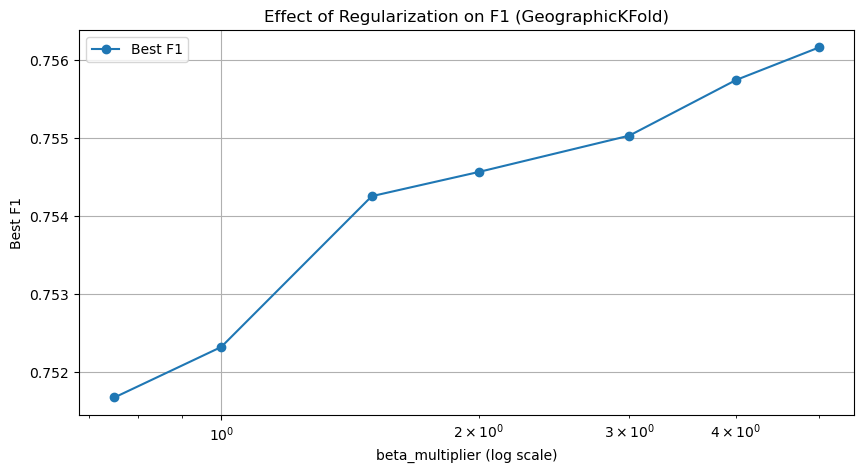

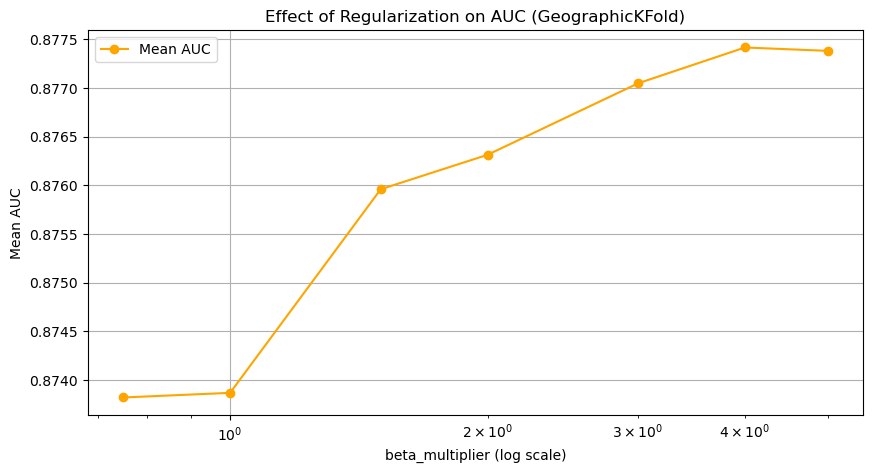

✅ Selected beta_multiplier=4.0 (CV mean_auc=0.8774)
🏁 Final tuned model (beta_multiplier=4.0)
AUC=0.9452  Precision=0.8102  Recall=0.8718  F1=0.8398
Best threshold=0.2060  Log-loss=0.3371  Prevalence=0.4078


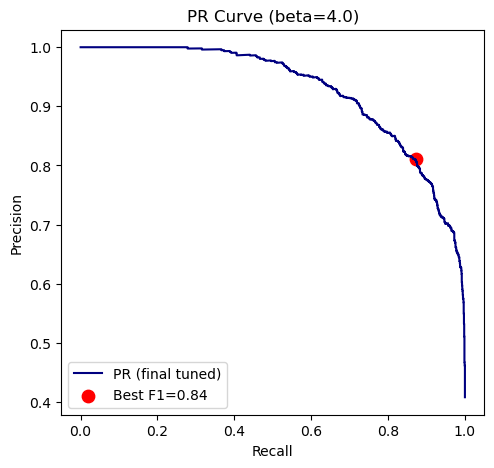

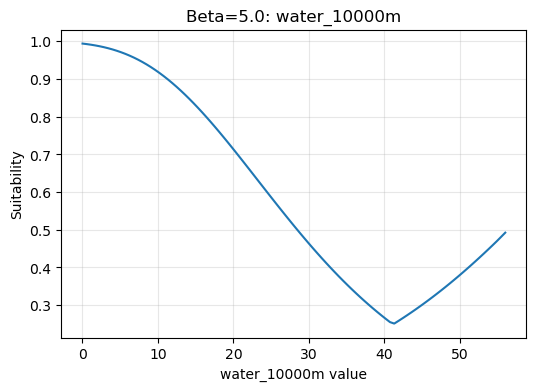

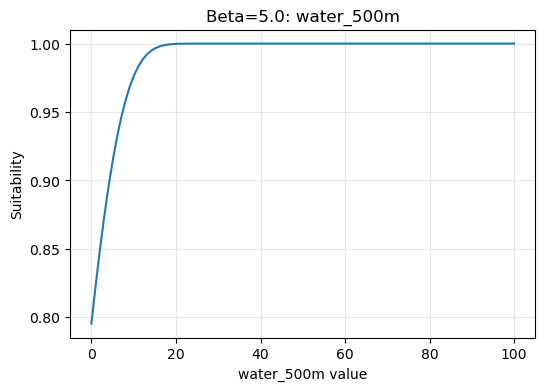

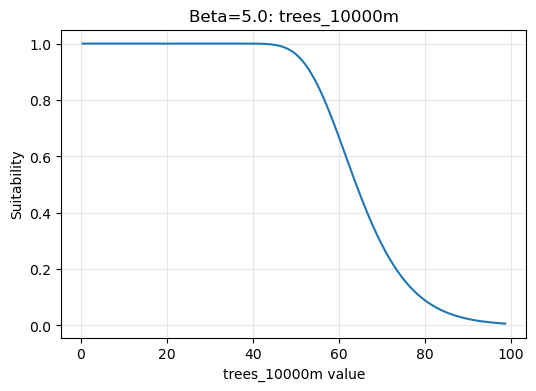

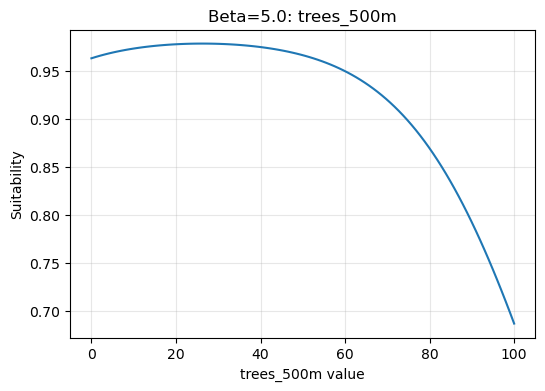

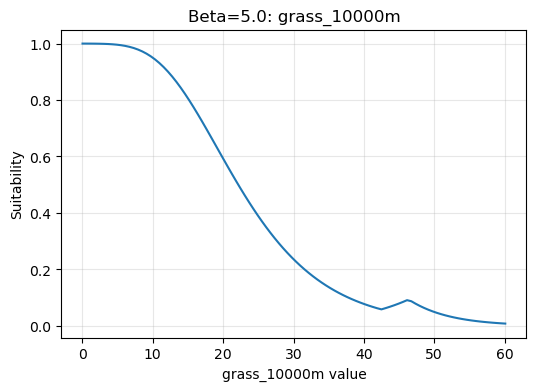

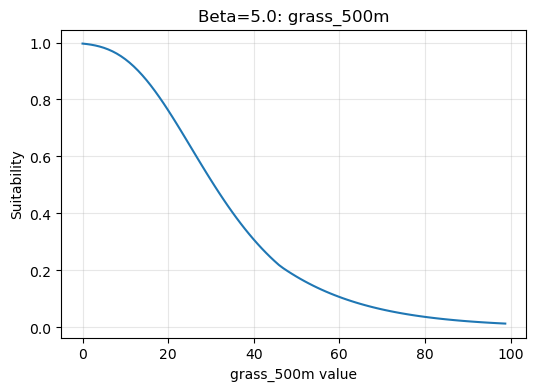

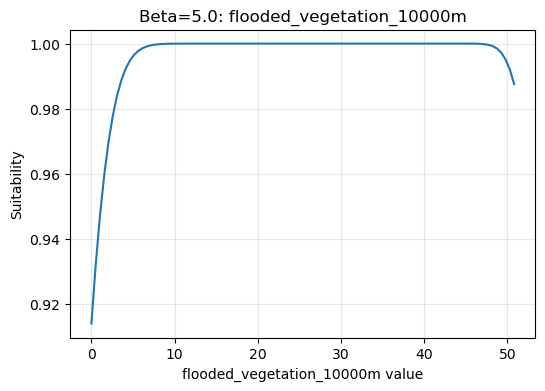

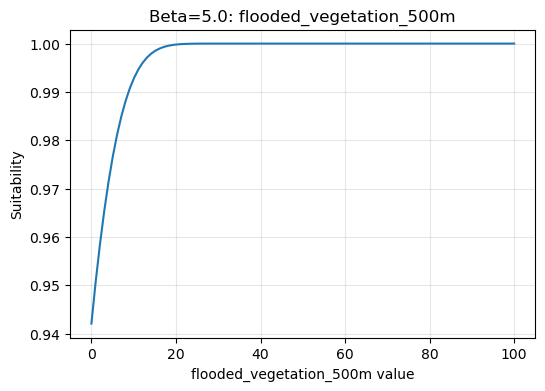

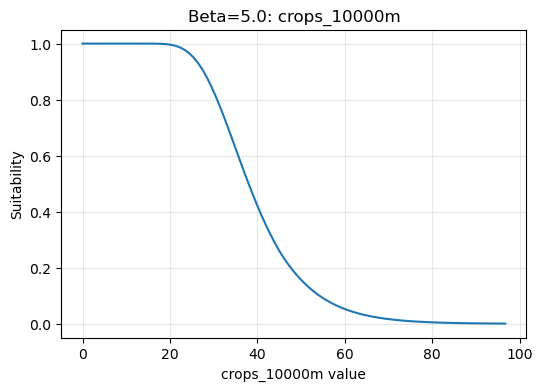

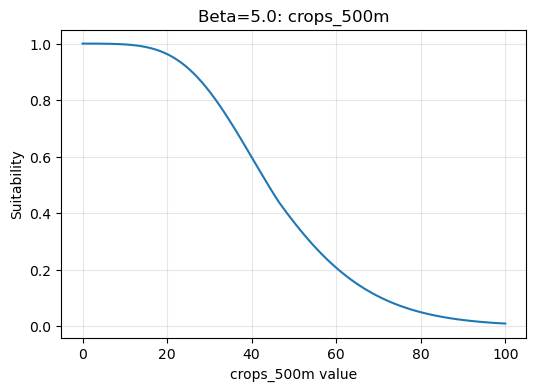

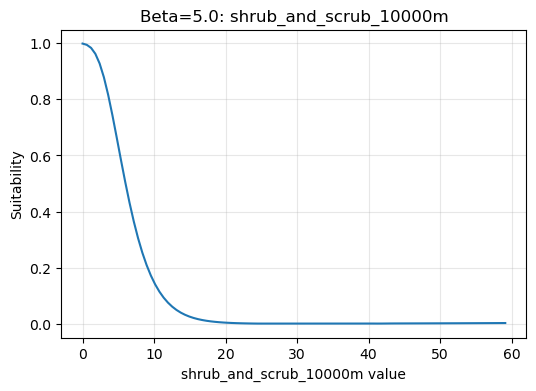

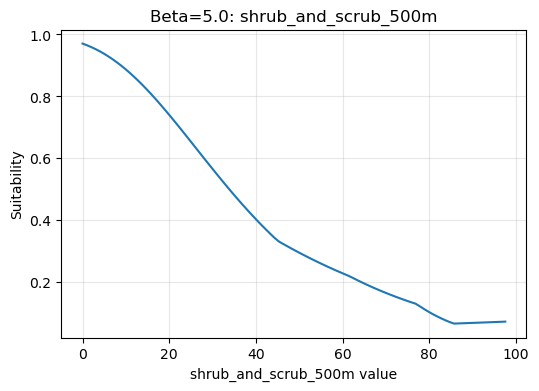

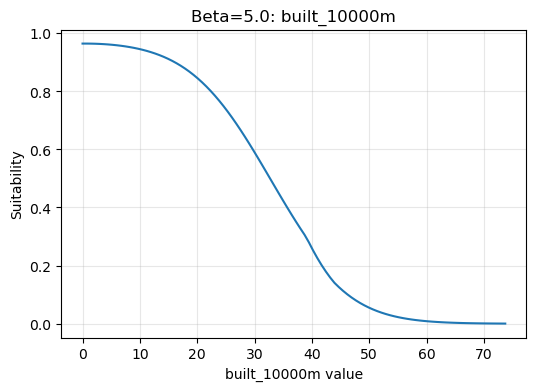

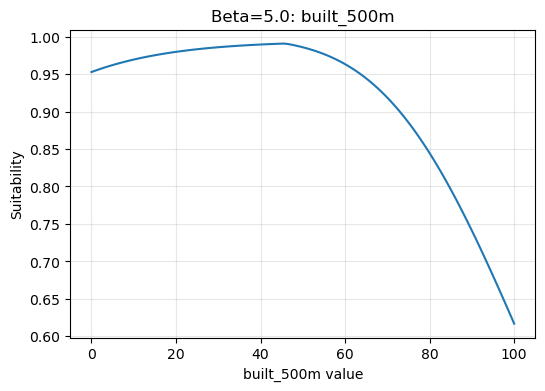

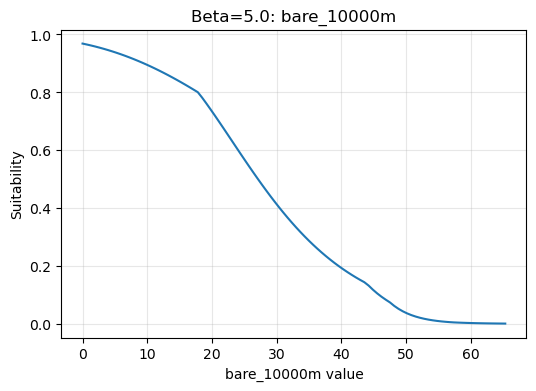

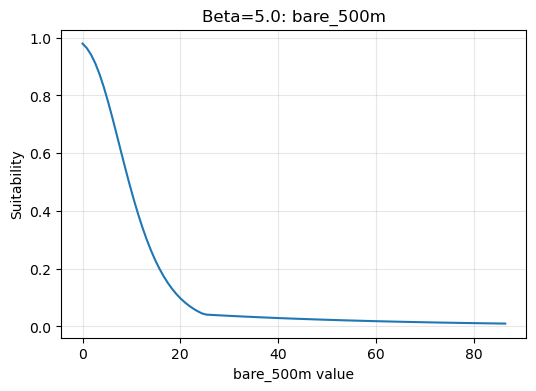

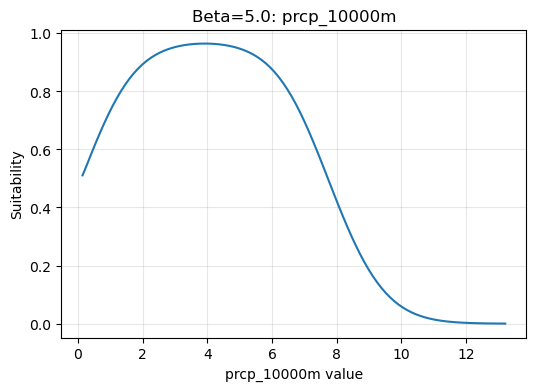

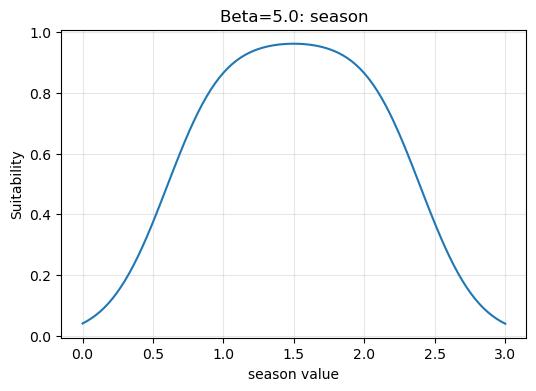

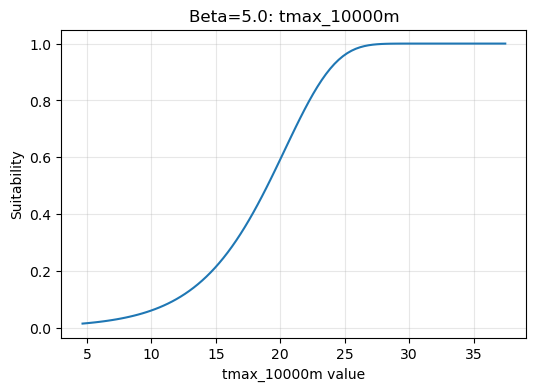

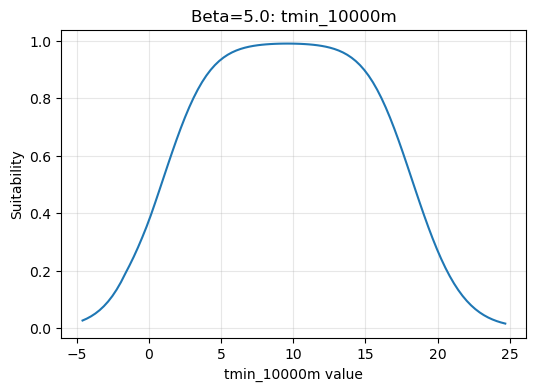

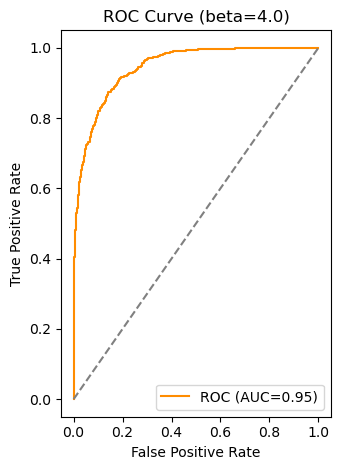

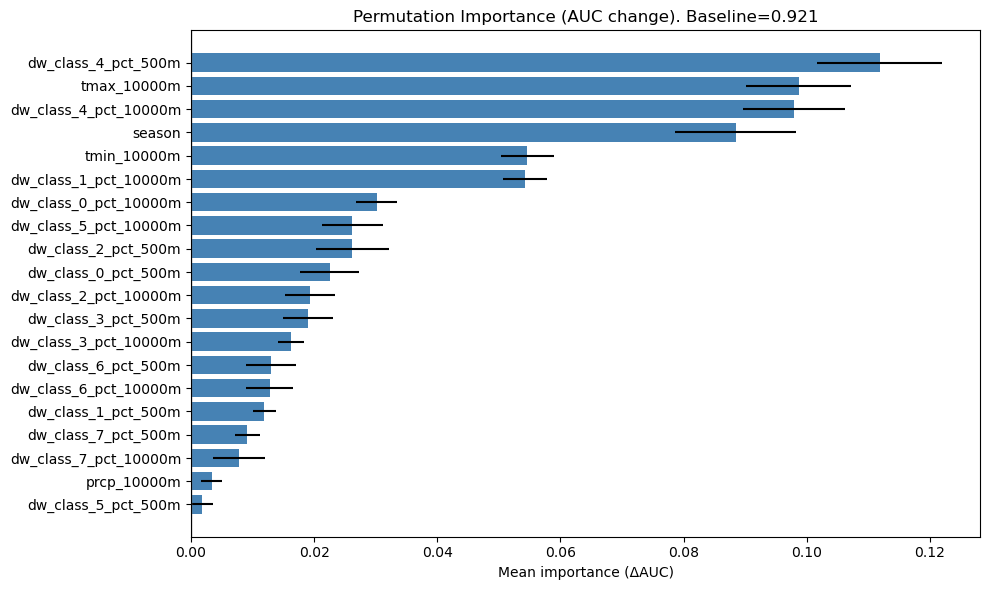

✅ Tuned final MaxEnt (PPP-equivalent) model saved, with diagnostics & importance.
{'best_beta': 4.0, 'selection_metric': 'mean_auc', 'final_auc': 0.945154970736366, 'final_f1': 0.8398425668636743, 'final_precision': 0.8101635514018691, 'final_recall': 0.8717787554996858, 'final_threshold': 0.2060148603805816, 'final_logloss': 0.3371171172999827, 'prevalence': 0.407844142527557, 'cv_name': 'GeographicKFold', 'reg_results': [{'beta_multiplier': 0.75, 'best_f1': 0.751677851855063, 'mean_auc': 0.8738198405186605}, {'beta_multiplier': 1.0, 'best_f1': 0.7523245979837914, 'mean_auc': 0.8738674670067674}, {'beta_multiplier': 1.5, 'best_f1': 0.754256526178943, 'mean_auc': 0.8759582791921648}, {'beta_multiplier': 2.0, 'best_f1': 0.7545662095498844, 'mean_auc': 0.8763123438707379}, {'beta_multiplier': 3.0, 'best_f1': 0.7550316268756745, 'mean_auc': 0.8770468638998608}, {'beta_multiplier': 4.0, 'best_f1': 0.7557446803557979, 'mean_auc': 0.877414860984536}, {'beta_multiplier': 5.0, 'best_f1': 0.756

In [20]:
# Prepare X, y, coords as you already do, then:
results = fit_maxent_with_tuning(
    X=X,
    y=y,
    #sw=sample_weight,
    coords=coords,
    outputdir=outputdir,
    sp=sp,
    selection_metric="mean_auc",#"best_f1" or "mean_auc"
    target_vars=target_vars
)

print(results)

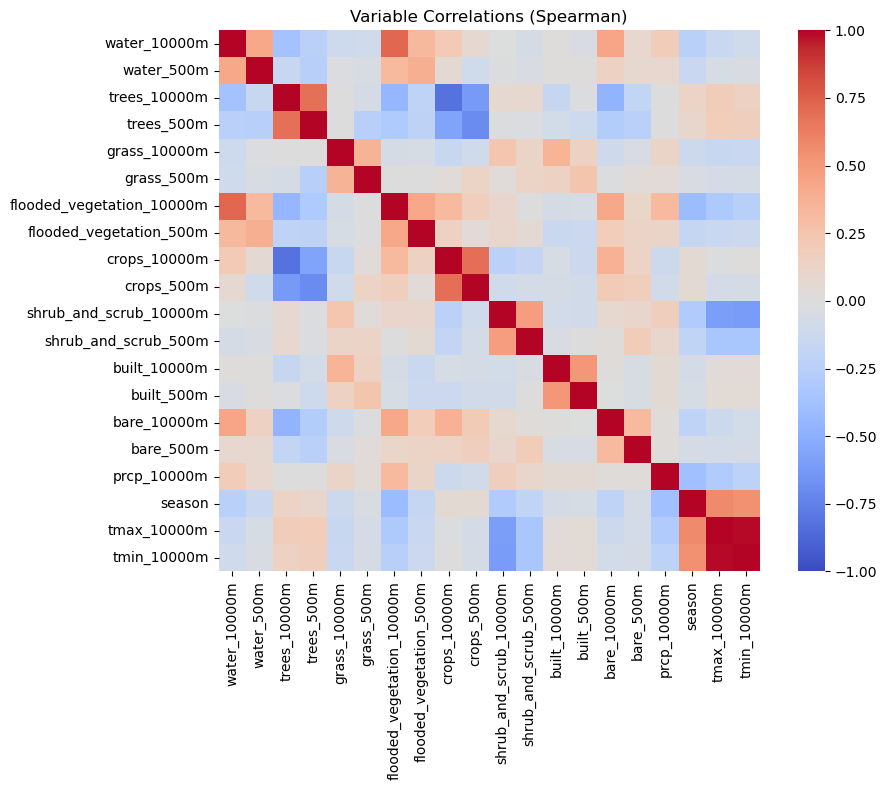

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# pick numeric columns (drop non-numeric)
dfX= X.drop(columns=["longitude", "latitude"]).rename(columns=rename_col)
num_df = dfX.select_dtypes(include='number')

# Choose method: 'pearson' or 'spearman'
corr = num_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=False, square=True)
plt.title('Variable Correlations (Spearman)')
plt.tight_layout()
plt.show()